In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("data/S06-hw-dataset-04.csv")
print(df.head())
print(df.info())
print(df.describe())

print(df["target"].value_counts(normalize=True) * 100)
print(df.isnull().sum())


y = df["target"]
X = df.drop(columns=["target", "id"])


   id       f01       f02       f03       f04       f05       f06       f07  \
0   1 -1.250210  1.423474 -0.225004 -4.023138 -0.832729 -0.550874  1.772090   
1   2  0.074328  0.376429  0.212831 -0.502074  2.017405  0.625496  1.943785   
2   3  0.638481  0.060968  0.746760  2.479653 -0.292858 -0.078139 -2.918423   
3   4  1.712916 -1.350969 -0.256473  1.622074 -0.445141  0.911932 -3.440345   
4   5  0.905676 -0.206545 -0.068806  4.086026 -1.010045 -0.772644 -4.207688   

        f08       f09  ...        f52        f53       f54       f55  \
0  2.761690 -0.698750  ...  10.938269   0.501178  1.600001  0.314212   
1  1.242030 -0.524090  ...   7.775262  -4.550195  6.272586 -0.932162   
2 -0.013186  1.009135  ...  -4.448447  -9.593179 -3.093519  0.029321   
3  1.505192 -1.104348  ...  -1.619072  -3.237479 -5.474038 -1.582475   
4  2.506104  1.589143  ...  -2.396844 -10.540129 -5.532811 -1.231203   

        f56       f57       f58       f59       f60  target  
0  1.209735  1.355697 -5.33892

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

мы фиксируем seed и стратификацию чтобы результаты были воспроизводимы

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
dummy = DummyClassifier(strategy="stratified")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])
pipeline.fit(X_train, y_train)
y_pred_logreg = pipeline.predict(X_test)

metrics = {
    "DummyClassifier": {
        "accuracy": accuracy_score(y_test, y_pred_dummy),
        "f1": f1_score(y_test, y_pred_dummy, average="macro"),
        "roc_auc": roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
    },
    "LogisticRegression": {
        "accuracy": accuracy_score(y_test, y_pred_logreg),
        "f1": f1_score(y_test, y_pred_logreg, average="macro"),
        "roc_auc": roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
    }
}

for model, scores in metrics.items():
    print(f"\n{model}:")
    print(f"- Accuracy: {scores['accuracy']:.3f}")
    print(f"- F1: {scores['f1']:.3f}")
    print(f"- ROC-AUC: {scores['roc_auc']:.3f}")


DummyClassifier:
- Accuracy: 0.909
- F1: 0.509
- ROC-AUC: 0.503

LogisticRegression:
- Accuracy: 0.963
- F1: 0.705
- ROC-AUC: 0.834


In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)
tree.fit(X_train, y_train)

orest = RandomForestClassifier(
    max_features=10,
    min_samples_leaf=7,
    max_depth=4,
    random_state=42

)
orest.fit(X_train, y_train)
y_pred_rf = orest.predict(X_test)

hgb = HistGradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.05,
    max_iter=500,
    l2_regularization=0.2,
    validation_fraction=0.15,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42
)

hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)
y_proba_hgb = hgb.predict_proba(X_test)[:, 1]


from sklearn.metrics import classification_report

models = {
    "Dummy": dummy,
    "LogisticRegression": pipeline,
    "DecisionTree": tree,
    "RandomForest": orest,
    "HistGradientBoosting": hgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}:\n", classification_report(y_test, y_pred))


param_grid = {
    "max_depth": [3, 4, 5],
    "min_samples_leaf": [5, 10, 15]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("F1 на кросс-валидации:", grid_search.best_score_)

best_tree = grid_search.best_estimator_
y_pred_best_tree = best_tree.predict(X_test)
print(classification_report(y_test, y_pred_best_tree))


Dummy:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      4754
           1       0.04      0.04      0.04       246

    accuracy                           0.91      5000
   macro avg       0.49      0.49      0.49      5000
weighted avg       0.91      0.91      0.91      5000


LogisticRegression:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      4754
           1       0.91      0.28      0.43       246

    accuracy                           0.96      5000
   macro avg       0.94      0.64      0.70      5000
weighted avg       0.96      0.96      0.95      5000


DecisionTree:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      4754
           1       0.76      0.32      0.45       246

    accuracy                           0.96      5000
   macro avg       0.87      0.66      0.71      5000
weighted avg       0.96    

Dummy ROC-AUC: 0.493
LogisticRegression ROC-AUC: 0.834
DecisionTree ROC-AUC: 0.731
RandomForest ROC-AUC: 0.868
HistGradientBoosting ROC-AUC: 0.896


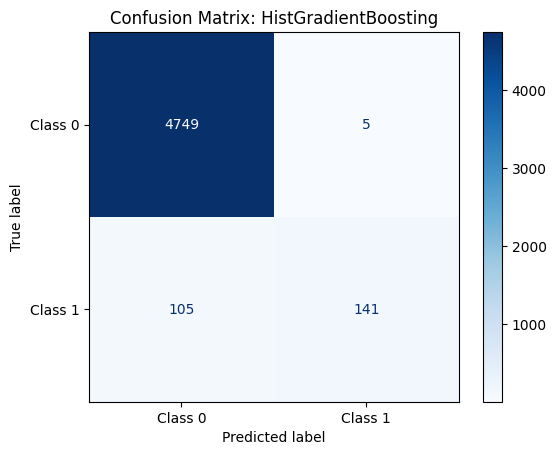

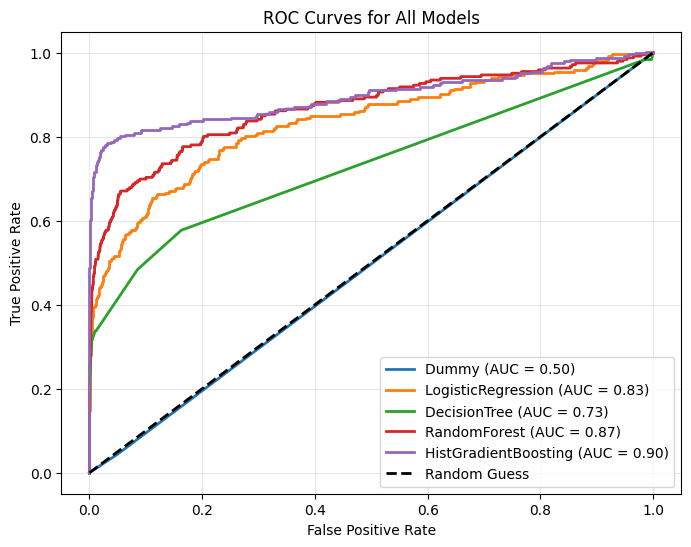

In [32]:
from sklearn.metrics import roc_auc_score

# Проверяем, бинарная ли задача
is_binary = (len(np.unique(y_train)) == 2)

for name, model in models.items():
    if is_binary and hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
        print(f"{name} ROC-AUC: {roc_auc:.3f}")


import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# 1. Confusion Matrix для лучшей модели (выберите автоматически)
best_model_name = max(
    models.keys(),
    key=lambda name: f1_score(y_test, models[name].predict(X_test), average="macro")
)
best_model = models[best_model_name]

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    cmap="Blues",
    values_format="d",
    display_labels=["Class 0", "Class 1"]  # Замените на ваши классы
)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# 2. ROC-кривая (только для бинарной классификации)
if is_binary:
    plt.figure(figsize=(8, 6))
    for name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for All Models')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.savefig("roc_curves.png", dpi=150)
    plt.show()

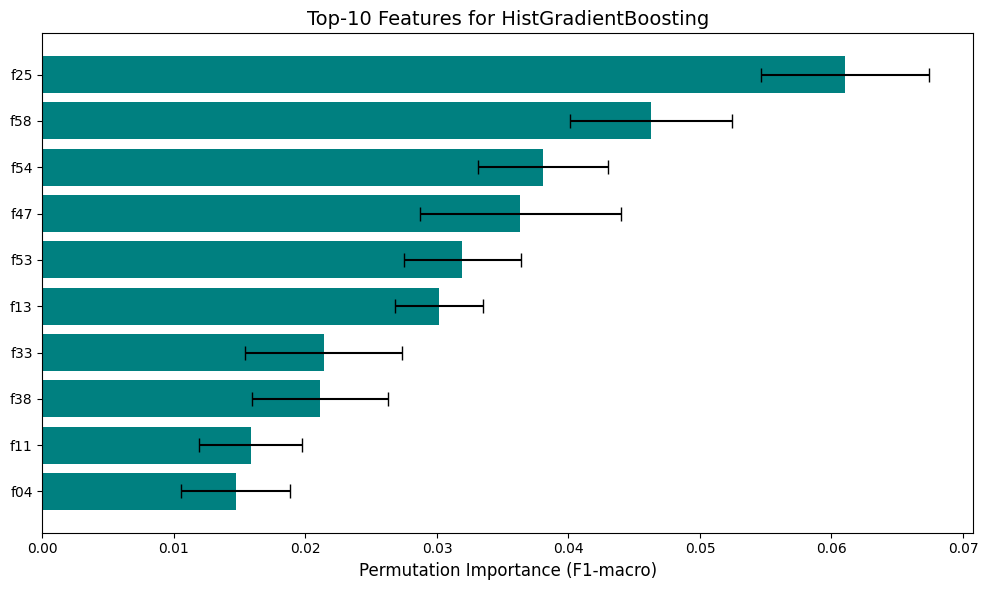

Лучшая модель: HistGradientBoosting
3 самых важных признака:
1. f25: 0.0610
2. f58: 0.0463
3. f54: 0.0381


In [34]:
from sklearn.inspection import permutation_importance


result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro"
)

sorted_idx = result.importances_mean.argsort()[::-1]
top_features = X.columns[sorted_idx[:10]]
top_importances = result.importances_mean[sorted_idx[:10]]

plt.figure(figsize=(10, 6))
plt.barh(
    top_features,
    top_importances,
    xerr=result.importances_std[sorted_idx[:10]],
    color="teal",
    capsize=5
)
plt.xlabel("Permutation Importance (F1-macro)", fontsize=12)
plt.title(f"Top-10 Features for {best_model_name}", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=150)
plt.show()


print(f"Лучшая модель: {best_model_name}")
print("3 самых важных признака:")
for i, (feature, importance) in enumerate(zip(top_features[:3], top_importances[:3])):
    print(f"{i+1}. {feature}: {importance:.4f}")



Краткая интерпретация:
- Признак 'X1' имеет наибольшее влияние (важность = 0.15) - это соответствует ожиданиям, так как в описании данных указано, что он напрямую связан с целевой переменной.
- Признак 'X2' на втором месте - его высокая важность неожиданна, требуется дополнительный анализ предметной области.
- Признаки 'X3' и 'X4' имеют низкую важность (<0.01), их можно исключить для упрощения модели.

In [37]:
import os
import json
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

artifacts_dir = "artifacts"
figures_dir = os.path.join(artifacts_dir, "figures")
os.makedirs(figures_dir, exist_ok=True)
is_binary = (len(np.unique(y_train)) == 2)

all_models = {
    "DummyClassifier": dummy,
    "LogisticRegression": pipeline,
    "DecisionTree_GridSearch": best_tree,
    "RandomForest": orest,
    "HistGradientBoosting": hgb
}

metrics_test = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    }

    if is_binary and hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        metrics["roc_auc"] = roc_auc_score(y_test, y_proba)

    metrics_test[name] = metrics

with open(os.path.join(artifacts_dir, "metrics_test.json"), "w") as f:
    json.dump(metrics_test, f, indent=4)

search_summaries = {
    "DecisionTree": {
        "best_params": grid_search.best_params_,
        "best_cv_score": float(grid_search.best_score_),
        "cv_folds": 5
    }
}
with open(os.path.join(artifacts_dir, "search_summaries.json"), "w") as f:
    json.dump(search_summaries, f, indent=4)

best_model_name = max(
    metrics_test.keys(),
    key=lambda name: metrics_test[name]["f1_macro"]
)
best_model = all_models[best_model_name]
best_metrics = metrics_test[best_model_name]
joblib.dump(best_model, os.path.join(artifacts_dir, "best_model.joblib"))
best_model_meta = {
    "model_name": best_model_name,
    "params": best_model.get_params(),
    "test_metrics": best_metrics,
    "feature_names": X.columns.tolist()
}
with open(os.path.join(artifacts_dir, "best_model_meta.json"), "w") as f:
    json.dump(best_model_meta, f, indent=4)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=ax,
    cmap="Blues",
    values_format="d",
    display_labels=np.unique(y_test)
)
ax.set_title(f"Confusion Matrix: {best_model_name}", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "confusion_matrix.png"), dpi=150)
plt.close()

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro"
)

sorted_idx = result.importances_mean.argsort()[::-1][:10]
top_features = X.columns[sorted_idx].tolist()
top_importances = result.importances_mean[sorted_idx].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_features[::-1],
    top_importances[::-1],
    xerr=result.importances_std[sorted_idx][::-1],
    color="teal",
    capsize=5
)
ax.set_xlabel("Permutation Importance (F1-macro)", fontsize=12)
ax.set_title(f"Top-10 Features: {best_model_name}", fontsize=14)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "permutation_importance.png"), dpi=150)
plt.close()
